In [1]:
# Import public packages and functions
import os
import pandas as pd
import numpy as np
import sys
import json
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp

import warnings
warnings.filterwarnings("ignore")

# inserting the lib folder to the compiler
sys.path.insert(0, './lib')
sys.path.insert(0, './utils/')

import utils_misc, utils_io, utils_plotting, utils_mutual_information, utils_statistics, utils_spectrogram, utils_plotting_spectrogram
from lib_data import DATA_IO

fs        = 2048
PATH_CURR = os.path.abspath(os.curdir)    # current code
PATH      = (str(Path(PATH_CURR).parent)) # data repository: upper directory where datasets situated
PATH_DATA = PATH + "\\data"               # the recordings data directory
SUB_LIST  = utils_misc.get_SUB_list(PATH_DATA)

In [2]:
df_TAPPING_MOTOR_events = pd.read_pickle(DATA_IO.path_events + "LFP_TAPPING_EVENTS_MOTOR_AREA.pkl")
df_TAPPING_MOTOR_events.patient.unique()

array(['008', '009', '012', '013', '014', '017', '019', '020', '021',
       '022', '023', '102', '103', '105', '108', '109', '110'],
      dtype=object)

# 1. Calculate Tap-Wise Time-Frequency Activity

In [4]:
df_TAPPING_MOTOR_events = pd.read_pickle(DATA_IO.path_events + "LFP_TAPPING_EVENTS_MOTOR_AREA.pkl")

## LID severity 3: noLID_noDOPA, noLID_DOPA, LID
df_TAPPING_MOTOR_events["severity"] = df_TAPPING_MOTOR_events.dyskinesia_arm.copy()
df_TAPPING_MOTOR_events.loc[(df_TAPPING_MOTOR_events['severity']!= "none")  , "severity"]     = 'LID'
df_TAPPING_MOTOR_events.loc[(df_TAPPING_MOTOR_events['severity']== "none") &
                            (df_TAPPING_MOTOR_events['event_start_time'] <= 30 ), "severity"] = 'noLID_noDOPA'
df_TAPPING_MOTOR_events.loc[(df_TAPPING_MOTOR_events['severity']== "none") & 
                            (df_TAPPING_MOTOR_events['event_start_time'] > 30 ) , "severity"] = 'noLID_DOPA'

df_controlateral        = df_TAPPING_MOTOR_events[df_TAPPING_MOTOR_events.event_laterality != df_TAPPING_MOTOR_events.LFP_hemisphere]
df_controlateral        = utils_misc.get_onset_and_offset_aligned_recordings(df_controlateral, fs=fs)
df_controlateral        = df_controlateral[["patient", "event_no", "LFP_hemisphere", "LFP_channel", "recording_onset_aligned","recording_offset_aligned","severity"]]
df_controlateral.reset_index(inplace=True, drop=True)

baseline_recordings     = utils_io.load_baseline_recordings(recording_type="LFP")

In [6]:
dataset                 = pd.DataFrame(df_controlateral)
dataset["hemisphere"]   = dataset.LFP_hemisphere
dataset["channel"]      = dataset.LFP_channel
dataset.reset_index(inplace=True, drop=True)

df_spectrogram          = utils_spectrogram.measure_normalized_multitaper_spectrograms_for_taps_and_channels(dataset, fs, baseline_recordings)
df_spectrogram.to_pickle(DATA_IO.path_events + "time_frequency_activity/LFP_TFA") 

Patient 008
>> right hemisphere : 05-02 channel is excluded!
>> right hemisphere : 06-03 channel is excluded!
>> right hemisphere : 07-04 channel is excluded!
>> right hemisphere : 08-05 channel is excluded!
>> right hemisphere : 09-06 channel is excluded!
>> right hemisphere : 10-07 channel is excluded!
---> baseline TFR measurement is completed...
------> left - LID - p_008_right_tapping1
------> left - LID - p_008_right_tapping2
------> left - LID - p_008_right_tapping3
------> left - LID - p_008_right_tapping4
------> left - LID - p_008_right_tapping5
------> left - LID - p_008_right_tapping6
------> left - LID - p_008_right_tapping7
------> left - LID - p_008_right_tapping8
------> left - LID - p_008_right_tapping9
------> left - LID - p_008_right_tapping10
------> left - LID - p_008_right_tapping11
------> left - LID - p_008_right_tapping12
------> left - LID - p_008_right_tapping13
------> left - LID - p_008_right_tapping14
------> left - LID - p_008_right_tapping15
------> left

# 2. Load Channel and Severity-Wise Time-Frequency Activity

In [4]:
df_spectrogram              = pd.read_pickle(DATA_IO.path_events + "time_frequency_activity/LFP_TFA") 
df_spectrogram_noLID_noDOPA = df_spectrogram[df_spectrogram.severity=="noLID_noDOPA"]
df_spectrogram_noLID_DOPA   = df_spectrogram[df_spectrogram.severity=="noLID_DOPA"]
df_spectrogram_LID          = df_spectrogram[df_spectrogram.severity=="LID"]

# filtering 
df_spectrogram_noLID_noDOPA = df_spectrogram_noLID_noDOPA[df_spectrogram_noLID_noDOPA.patient.isin(df_spectrogram_noLID_noDOPA.patient.value_counts()[lambda x: x >= 5].index)]
df_spectrogram_noLID_DOPA   = df_spectrogram_noLID_DOPA[df_spectrogram_noLID_DOPA.patient.isin(df_spectrogram_noLID_DOPA.patient.value_counts()[lambda x: x >= 5].index)]
df_spectrogram_LID          = df_spectrogram_LID[df_spectrogram_LID.patient.isin(df_spectrogram_LID.patient.value_counts()[lambda x: x >= 5].index)]

# 3. Plot Spectrograms

In [6]:
def average_spectrograms_per_event(dataset, alignment):
    
    averaged_rows = []
    grouped       = dataset[dataset.alignment_type==alignment].groupby(["patient", "hemisphere", "severity", "event_no", "alignment_type"])

    for (patient, hemisphere, severity, event_no, alignment_type), group in grouped:
        
        spectrograms      = np.stack(group["spectrogram"].values)  # stack all spectrograms from different channels
        mean_spectrograms = np.nanmean(spectrograms, axis=0)       # take the mean across channels (axis=0)
        averaged_rows.append({"patient": patient, "hemisphere": hemisphere, "severity": severity, "event_no": event_no, "spectrogram_mean": mean_spectrograms})

    df_mean = pd.DataFrame(averaged_rows)
    
    return df_mean

In [7]:
TFR_avg_offset_noLID_noDOPA = average_spectrograms_per_event(df_spectrogram_noLID_noDOPA, alignment="offset")
TFR_avg_offset_noLID_noDOPA = np.nanmean(np.stack(TFR_avg_offset_noLID_noDOPA["spectrogram_mean"].values), axis=0)
TFR_avg_offset_noLID_DOPA   = average_spectrograms_per_event(df_spectrogram_noLID_DOPA, alignment="offset")
TFR_avg_offset_noLID_DOPA   = np.nanmean(np.stack(TFR_avg_offset_noLID_DOPA["spectrogram_mean"].values), axis=0)
TFR_avg_offset_LID          = average_spectrograms_per_event(df_spectrogram_LID, alignment="offset")
TFR_avg_offset_LID          = np.nanmean(np.stack(TFR_avg_offset_LID["spectrogram_mean"].values), axis=0)

In [11]:
TFR_avg_onset_noLID_noDOPA  = average_spectrograms_per_event(df_spectrogram_noLID_noDOPA, alignment="onset")
TFR_avg_onset_noLID_noDOPA  = np.nanmean(np.stack(TFR_avg_onset_noLID_noDOPA["spectrogram_mean"].values), axis=0)
TFR_avg_onset_noLID_DOPA    = average_spectrograms_per_event(df_spectrogram_noLID_DOPA, alignment="onset")
TFR_avg_onset_noLID_DOPA    = np.nanmean(np.stack(TFR_avg_onset_noLID_DOPA["spectrogram_mean"].values), axis=0)
TFR_avg_onset_LID           = average_spectrograms_per_event(df_spectrogram_LID, alignment="onset")
TFR_avg_onset_LID           = np.nanmean(np.stack(TFR_avg_onset_LID["spectrogram_mean"].values), axis=0)

<Figure size 640x480 with 0 Axes>

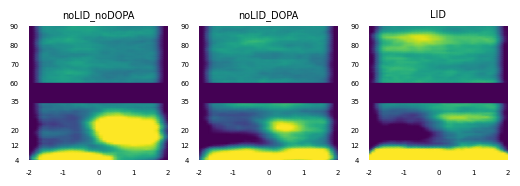

In [8]:
plt             = utils_plotting.get_figure_template()
ax_noLID_noDOPA = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_noLID_DOPA   = plt.subplot2grid((80, 40), (0, 12) , colspan=10, rowspan=17)
ax_LID          = plt.subplot2grid((80, 40), (0, 24), colspan=10, rowspan=17)

ax_noLID_noDOPA = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_noDOPA, group = "noLID_noDOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_noDOPA)
ax_noLID_DOPA   = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_DOPA, group = "noLID_DOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_DOPA)
ax_LID          = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_LID, group = "LID", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_LID)

plt.savefig(DATA_IO.path_figure + "spectrogram/motor_stn_spectrogram_offset.svg", dpi=1200)

<Figure size 640x480 with 0 Axes>

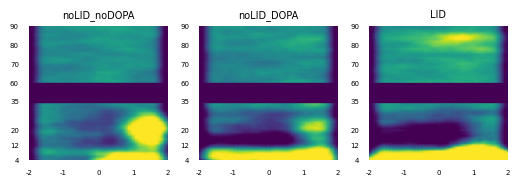

In [13]:
plt             = utils_plotting.get_figure_template()
ax_noLID_noDOPA = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
ax_noLID_DOPA   = plt.subplot2grid((80, 40), (0, 12) , colspan=10, rowspan=17)
ax_LID          = plt.subplot2grid((80, 40), (0, 24), colspan=10, rowspan=17)

ax_noLID_noDOPA = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_onset_noLID_noDOPA, group = "noLID_noDOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_noDOPA)
ax_noLID_DOPA   = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_onset_noLID_DOPA, group = "noLID_DOPA", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_DOPA)
ax_LID          = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_onset_LID, group = "LID", time_vector=np.linspace(-2,2,40), 
                                                                   vmin=-30, vmax=30, cmap="viridis", axis=ax_LID)

plt.savefig(DATA_IO.path_figure + "spectrogram/motor_stn_spectrogram_onset.svg", dpi=1200)

# 4. Plotting Patient-Wise

<Figure size 640x480 with 0 Axes>

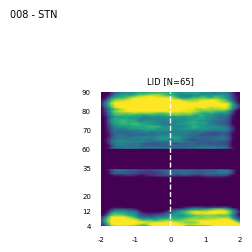

<Figure size 640x480 with 0 Axes>

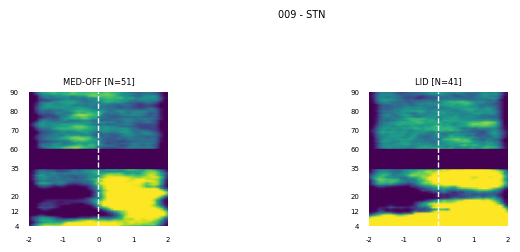

<Figure size 640x480 with 0 Axes>

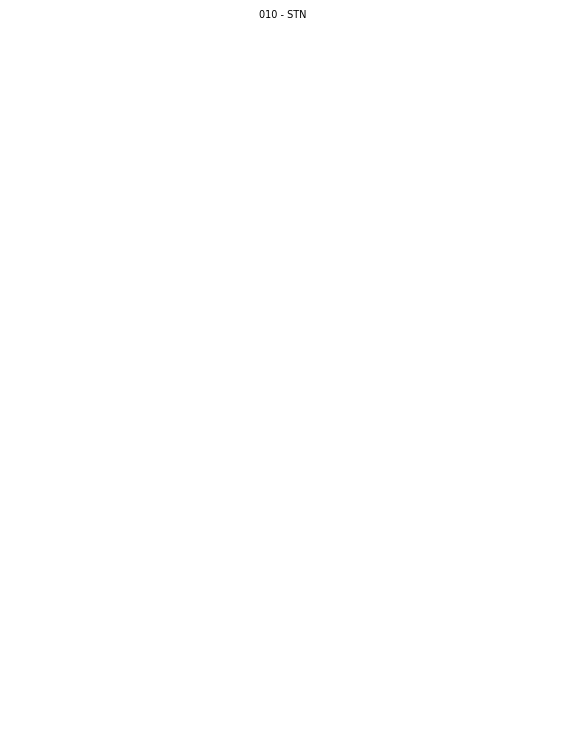

<Figure size 640x480 with 0 Axes>

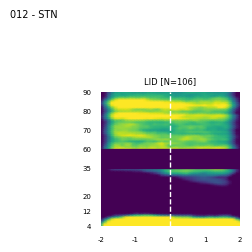

<Figure size 640x480 with 0 Axes>

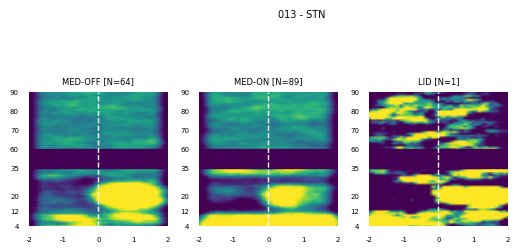

<Figure size 640x480 with 0 Axes>

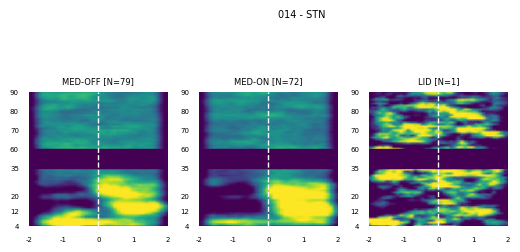

<Figure size 640x480 with 0 Axes>

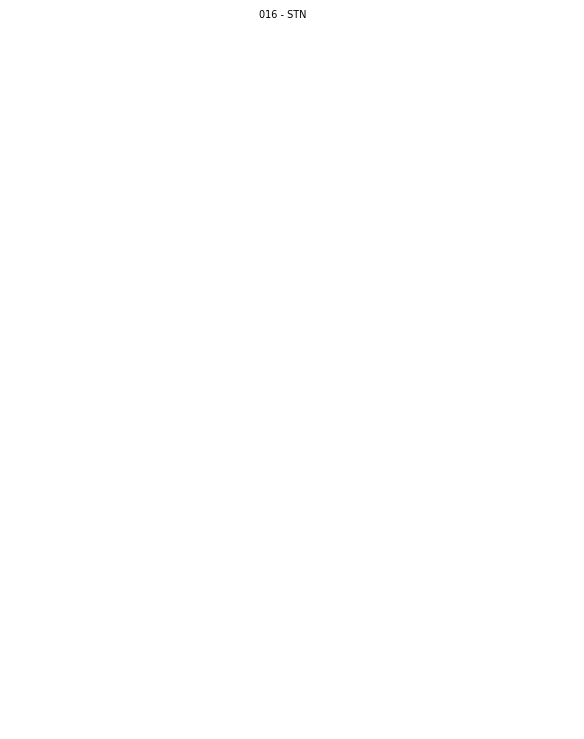

<Figure size 640x480 with 0 Axes>

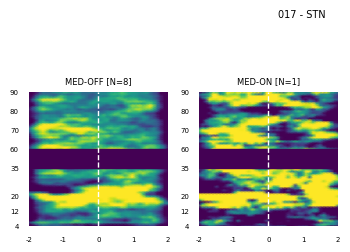

<Figure size 640x480 with 0 Axes>

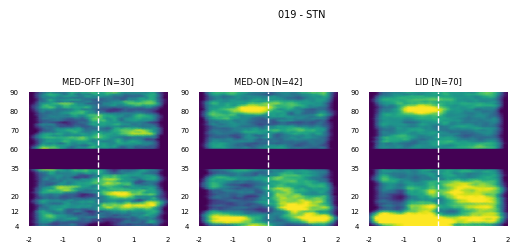

<Figure size 640x480 with 0 Axes>

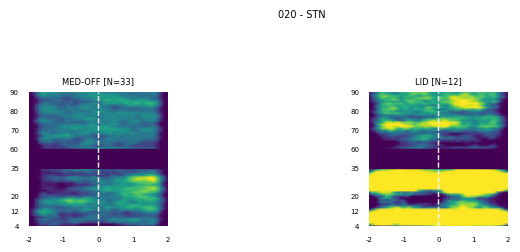

<Figure size 640x480 with 0 Axes>

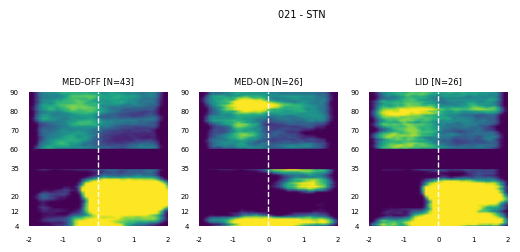

<Figure size 640x480 with 0 Axes>

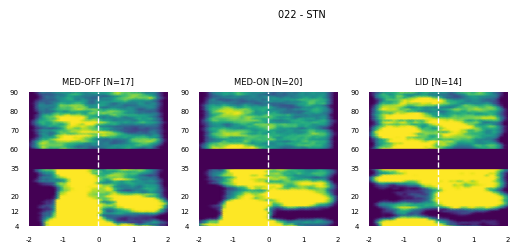

<Figure size 640x480 with 0 Axes>

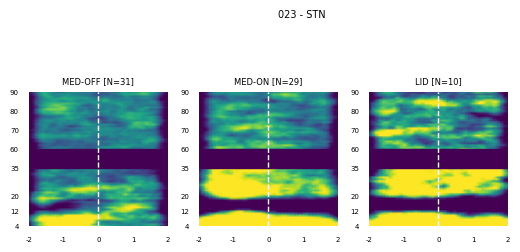

<Figure size 640x480 with 0 Axes>

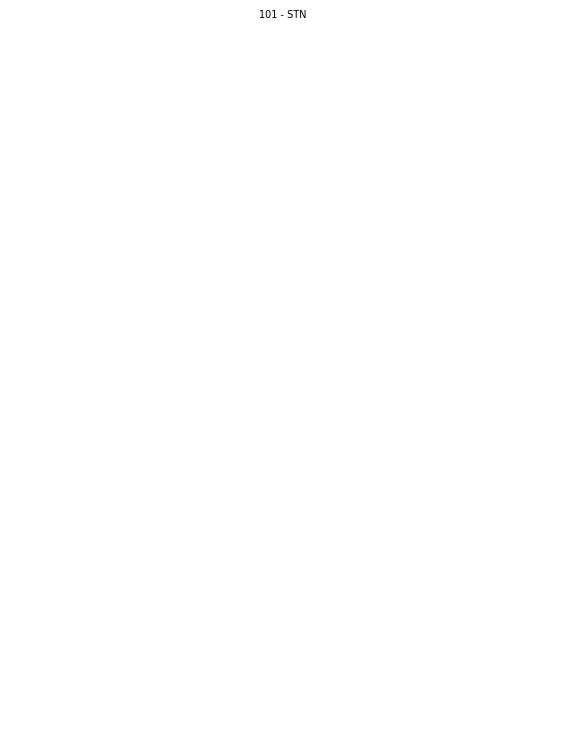

<Figure size 640x480 with 0 Axes>

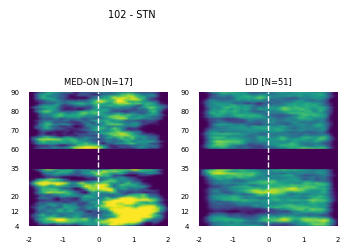

<Figure size 640x480 with 0 Axes>

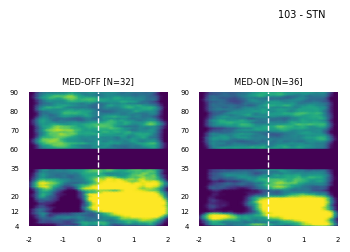

<Figure size 640x480 with 0 Axes>

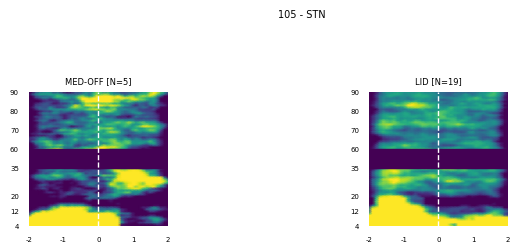

<Figure size 640x480 with 0 Axes>

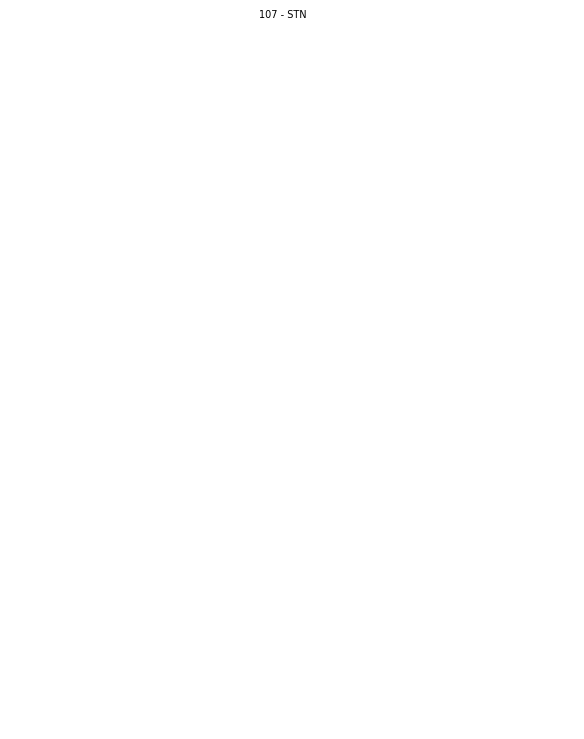

<Figure size 640x480 with 0 Axes>

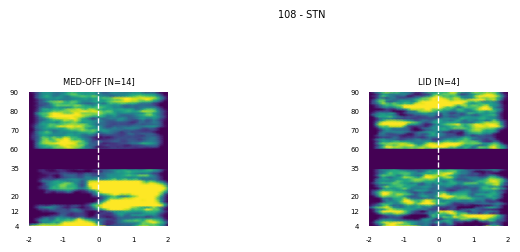

<Figure size 640x480 with 0 Axes>

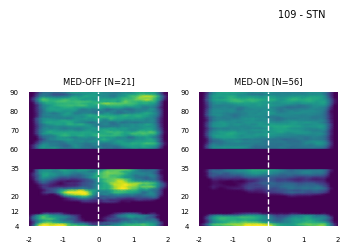

<Figure size 640x480 with 0 Axes>

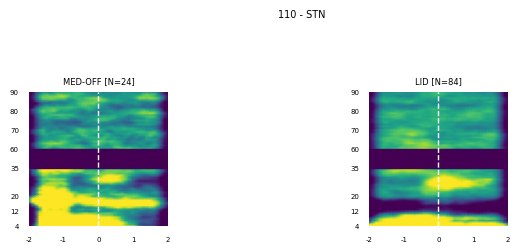

In [47]:
for SUB in SUB_LIST:

    TFR_avg_offset_noLID_noDOPA          = average_spectrograms_per_event(df_spectrogram_noLID_noDOPA[df_spectrogram_noLID_noDOPA.patient==SUB], alignment="offset")
    N_noLID_noDOPA                       = TFR_avg_offset_noLID_noDOPA.shape[0]
    try    : TFR_avg_offset_noLID_noDOPA = np.nanmean(np.stack(TFR_avg_offset_noLID_noDOPA["spectrogram_mean"].values), axis=0)
    except : TFR_avg_offset_noLID_noDOPA = np.nan
        
    TFR_avg_offset_noLID_DOPA          = average_spectrograms_per_event(df_spectrogram_noLID_DOPA[df_spectrogram_noLID_DOPA.patient==SUB], alignment="offset")
    N_noLID_DOPA                       = TFR_avg_offset_noLID_DOPA.shape[0]
    try    : TFR_avg_offset_noLID_DOPA = np.nanmean(np.stack(TFR_avg_offset_noLID_DOPA["spectrogram_mean"].values), axis=0)
    except : TFR_avg_offset_noLID_DOPA = np.nan
        
    TFR_avg_offset_LID          = average_spectrograms_per_event(df_spectrogram_LID[df_spectrogram_LID.patient==SUB], alignment="offset")
    N_LID                       = TFR_avg_offset_LID.shape[0]
    try    : TFR_avg_offset_LID = np.nanmean(np.stack(TFR_avg_offset_LID["spectrogram_mean"].values), axis=0)
    except : TFR_avg_offset_LID = np.nan

    ####################################################################################################################
    
    plt             = utils_plotting.get_figure_template()

    if not np.isscalar(TFR_avg_offset_noLID_noDOPA):
        ax_noLID_noDOPA = plt.subplot2grid((80, 40), (0, 0) , colspan=10, rowspan=17)
        ax_noLID_noDOPA = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_noDOPA, group = "noLID_noDOPA", time_vector=np.linspace(-2,2,40), 
                                                                       vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_noDOPA)
        ax_noLID_noDOPA.set_title(f"MED-OFF [N={N_noLID_noDOPA}]", fontsize=6)
        ax_noLID_noDOPA.axvline(x=0, color='w', linestyle='--', linewidth=1)

    if not np.isscalar(TFR_avg_offset_noLID_DOPA):
        ax_noLID_DOPA   = plt.subplot2grid((80, 40), (0, 12) , colspan=10, rowspan=17)
        ax_noLID_DOPA   = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_noLID_DOPA, group = "noLID_DOPA", time_vector=np.linspace(-2,2,40), 
                                                                           vmin=-30, vmax=30, cmap="viridis", axis=ax_noLID_DOPA)
        ax_noLID_DOPA.set_title(f"MED-ON [N={N_noLID_DOPA}]", fontsize=6)
        ax_noLID_DOPA.axvline(x=0, color='w', linestyle='--', linewidth=1)
        
    if not np.isscalar(TFR_avg_offset_LID):
        ax_LID          = plt.subplot2grid((80, 40), (0, 24), colspan=10, rowspan=17)
        ax_LID          = utils_plotting_spectrogram.plot_mean_spectrogram(TFR_avg_offset_LID, group = "LID", time_vector=np.linspace(-2,2,40), 
                                                                           vmin=-30, vmax=30, cmap="viridis", axis=ax_LID)
        ax_LID.set_title(f"LID [N={N_LID}]", fontsize=6)
        ax_LID.axvline(x=0, color='w', linestyle='--', linewidth=1)

    plt.suptitle(f"{SUB} - STN", fontsize=7)
    
    plt.savefig(DATA_IO.path_figure + f"spectrogram/patients/{SUB}_STN_offset.svg", dpi=1200)

In [25]:
TFR_avg_offset_LID.shape

(87, 40)

In [27]:
TFR_avg_offset_noLID_noDOPA          = average_spectrograms_per_event(df_spectrogram_noLID_noDOPA[df_spectrogram_noLID_noDOPA.patient==SUB], alignment="offset")

In [41]:
N_noLID_noDOPA

24